# BM4 projection comparison with the saved standard reference

Compare `BM4Midpoint` and `BM4Implicit` through **normalized time 35** using `data/trajectory/h5_three_radial_dop853_t35`. Use the saved time coordinate directly; do not multiply the horizon by a period or interpret the artifact as a request for 35 additional oscillations.

Both methods use the standard three radial initial positions and physical-state formulation, with `h = 0.1`: 350 complete steps, 351 saved states. The initial spatial radii are `(0.1, 0.2, 0.3)` times the **cell period**, at angle zero toward +x. These differ from the earlier 20-time-unit experiment. Velocities follow the guiding-center field and are not independent initial data.

All scientific parameters, saved-reference validation, reproducible computation, tables, figures, and video are available from this notebook. Existing verified results are loaded by default. Enable `run_integrations` to repeat the BM4 campaign; reference integrations are always reused.

In [1]:
from pathlib import Path
from dataclasses import asdict
import json
import numpy as np
from IPython.display import display, Markdown, Image, Video
from diagnostics import load_reference_trajectory
from diagnostics.paths import find_project_root
from diagnostics.bm4_comparison import load_bm4_comparison, save_bm4_comparison
from potential import load_gc2d_h5_potential
from studies.initial_conditions import radial_gc_configuration, domain_center
from studies.bm4_projection_comparison import (
    BM4ProjectionComparisonConfig, run_bm4_projection_comparison,
    audit_saved_reference_refinement, saved_sample_indices, summarize_bm4_particles,
)
from visualization.bm4_projection_comparison import render_bm4_comparison

root = find_project_root(Path.cwd())
source = root / 'data/potential/V1/PHI_2.h5'
reference_directory = root / 'data/trajectory/h5_three_radial_dop853_t35'
coarse_reference_directory = root / 'outputs/developements/accuracy/h5_three_radial/v2'
output = root / 'notebooks/developements/bm4_projection_comparison/standard_t35'

## Units and numerical precision

Positions use `x_hat = 2*pi*(R-R0)/lambda` and `y_hat = 2*pi*(Z-Z0)/lambda`, with `lambda = 0.06 m`. The potential and guiding-center equations use the project's nondimensional HDF5 formulation. The horizon is exactly the reference's normalized `[0,35]` interval. `rho = 0.3` is the normalized gyro-radius, distinct from the initial radial distances. Energy errors compare the physical Hamiltonian **history** to DOP853; conservation alone does not validate a trajectory.

All arithmetic is IEEE 754 float64 (53-bit significand; machine epsilon about `2.22e-16`). Requested integration tolerances do not imply that many accurate digits in the trajectory. DOP853 uses `rtol=5e-13`, `atol=5e-15`, `max_step=0.0025`. The stored coarser DOP853 run uses `1e-12`, `1e-14`, and `0.005`, so both tolerances and maximum step are refined by a factor of two. No independent analytic solution is available for this interpolated measured field.

In [2]:
T_END = 35.0
INTEGRATION_STEP = 0.1
SAVE_INTERVAL = 0.1
RADIAL_FRACTIONS = (0.1, 0.2, 0.3)  # fractions of full cell period
RADIAL_ANGLE = 0.0
potential_parameters = dict(B=1.5, characteristic_length=0.06, indx=(0, 1),
    interpolation_order=3, spatial_normalization='characteristic_length')
config = BM4ProjectionComparisonConfig(
    t_span=(0.0, T_END), integration_step=INTEGRATION_STEP, save_interval=SAVE_INTERVAL,
    rho=0.3, coupling_frequency=float(np.pi / 8),
    absolute_tolerance=1e-12, relative_tolerance=1e-11, max_iterations=40,
    jacobian_relative_step=float(np.cbrt(np.finfo(float).eps)),
    reference_relative_tolerance=5e-13, reference_absolute_tolerance=5e-15,
    reference_maximum_step=0.0025,
    audit_relative_tolerance=5e-14, audit_absolute_tolerance=5e-16,
    audit_maximum_step=0.00125,
    timing_warmups=1, timing_repeats=3, distance_convention='periodic', progress=True,
)
ANIMATION_FRAMES = 201
ANIMATION_FPS = 10
run_integrations = not (output / 'results.npz').exists()
render_outputs = True  # refresh per-particle figures without rerunning integrations
potential = load_gc2d_h5_potential(source, **potential_parameters)
configuration = radial_gc_configuration(potential, radial_fractions=RADIAL_FRACTIONS, angle=RADIAL_ANGLE)
x0, y0 = configuration.positions(configuration.initial_state)
initial_metadata = {'geometry': 'one radial segment', 'center': list(domain_center(potential)),
    'radial_fractions': list(RADIAL_FRACTIONS), 'angle_radians': RADIAL_ANGLE,
    'x': x0.tolist(), 'y': y0.tolist()}
potential_metadata = {'source': str(source), **potential_parameters}
display(Markdown('| Particle | x(0) | y(0) | Radius / cell period |\n|---|---:|---:|---:|\n' +
    '\n'.join(f'| P{i+1} | {x0[i]:.9f} | {y0[i]:.9f} | {RADIAL_FRACTIONS[i]:g} |' for i in range(3))))

| Particle | x(0) | y(0) | Radius / cell period |
|---|---:|---:|---:|
| P1 | 11.309733553 | 9.424777961 | 0.1 |
| P2 | 13.194689145 | 9.424777961 | 0.2 |
| P3 | 15.079644737 | 9.424777961 | 0.3 |

In [3]:
# Loading checks array checksums. The refinement helper also checks the actual
# effective-field fingerprint, grid, rho, potential metadata, and initial states.
reference = load_reference_trajectory(reference_directory)
coarse_reference = load_reference_trajectory(coarse_reference_directory)
validation_arrays, validation_summary = audit_saved_reference_refinement(
    potential, configuration, reference, coarse_reference, config=config,
    potential_metadata=potential_metadata, initial_condition_metadata=initial_metadata,
)
assert reference.states.shape == (6, 3501)
assert reference.times[0] == 0.0 and reference.times[-1] == T_END
assert reference.states.dtype == np.float64
np.testing.assert_array_equal(reference.initial_state, configuration.initial_state)
display(Markdown('| Particle | Maximum DOP853 refinement discrepancy |\n|---|---:|\n' +
    '\n'.join(f'| P{i+1} | {validation_summary["refinement_maximum_per_particle"][i]:.6e} |' for i in range(3))))
print('Reference checksum:', reference.metadata['trajectory_sha256'])
print('No reference integration was repeated.')

| Particle | Maximum DOP853 refinement discrepancy |
|---|---:|
| P1 | 1.512943e-04 |
| P2 | 7.545511e-07 |
| P3 | 6.911308e-08 |

Reference checksum: 9681bc2662210314a34f6d8eb3a6ee55d79a77d2a81283d3aef42c15c2e895e4
No reference integration was repeated.


## Per-particle interpretation and joint timing

DOP853 refinement uses all 3501 saved reference nodes. BM4 errors use the common 351-node grid, selecting saved samples without interpolation or extrapolation. The refinement discrepancy is empirical, not a rigorous error bound.

Each trajectory/energy RMS is a time RMS for **one particle**, with no particle averaging. Positions are normalized and unwrapped; trajectory errors use minimum-image periodic distances. Energy errors compare the physical Hamiltonian history.

Timings use one warm-up and three complete serial integrations per method, alternating order and limiting BLAS to one thread. They measure **all three particles jointly**. There are no independently measured per-particle runtimes; dividing the joint time by three would not supply them. Reference generation and multiplier-observer replay are excluded.

BM4Implicit's multiplier has components (mu_x, mu_y) for each particle, saved at every accepted step. The tables report the arithmetic mean, RMS, maximum and final value of each particle's infinity norm across those steps. BM4Midpoint has no multiplier. Both methods project once after the complete twelve-stage BM4 map.

In [4]:
if run_integrations:
    arrays, summary = run_bm4_projection_comparison(
        potential, configuration, config=config, saved_reference=reference,
        potential_metadata=potential_metadata, initial_condition_metadata=initial_metadata,
    )
    arrays.update(validation_arrays)
    summary['reference_validation'] = validation_summary
    metadata = {'config': asdict(config), 'source': str(source),
        'potential_parameters': potential_parameters, 'initial_geometry': initial_metadata,
        'reference_directory': str(reference_directory), 'reference_metadata': dict(reference.metadata),
        'summary': summary}
    save_bm4_comparison(output / 'results.npz', arrays, metadata)
else:
    arrays, metadata = load_bm4_comparison(output / 'results.npz')
    assert json.loads(json.dumps(asdict(config))) == metadata['config']
    assert metadata['reference_metadata']['trajectory_sha256'] == reference.metadata['trajectory_sha256']
    assert metadata['summary']['reference_validation']['coarse_checksum'] == coarse_reference.metadata['trajectory_sha256']
    np.testing.assert_array_equal(arrays['initial_state'], configuration.initial_state)
    indices = saved_sample_indices(reference, arrays['times'])
    np.testing.assert_array_equal(arrays['DOP853.states'], reference.states[:, indices])
assert arrays['times'].size == 351
assert arrays['BM4Implicit.mu'].shape == (6, 350)
assert metadata['summary']['step_count'] == 350
particles = summarize_bm4_particles(arrays)
display(Markdown('| Particle | Method | Trajectory RMS | Final distance | Max distance | Energy RMS | Max absolute energy error |\n|---|---|---:|---:|---:|---:|---:|\n' +
    '\n'.join('| ' + p['particle'] + ' | ' + name + ' | ' +
        ' | '.join(f'{r[k]:.6e}' for k in ('trajectory_rms', 'trajectory_final', 'trajectory_max', 'energy_rms', 'energy_max')) + ' |'
        for p in particles for name, r in p['methods'].items())))
display(Markdown('### Multiplier infinity norm per particle (BM4Implicit)\n\n| Particle | Mean | RMS | Maximum | Final |\n|---|---:|---:|---:|---:|\n' +
    '\n'.join('| ' + p['particle'] + ' | ' + ' | '.join(f'{p["mu"][k]:.6e}' for k in ('mean', 'rms', 'maximum', 'final')) + ' |' for p in particles)))
display(Markdown('### Initial and final positions (normalized, unwrapped)\n\n| Particle | State / final method | x | y |\n|---|---|---:|---:|\n' +
    '\n'.join(f'| {p["particle"]} | {name} | {xy[0]:.9f} | {xy[1]:.9f} |' for p in particles for name, xy in p['positions'].items())))
rows = metadata['summary']['methods']
display(Markdown('### Joint runtime for all three particles\n\n| Method | Median s | Q1 s | Q3 s |\n|---|---:|---:|---:|\n' +
    '\n'.join(f'| {name} | {r["runtime_median_seconds"]:.3f} | {r["runtime_q1_seconds"]:.3f} | {r["runtime_q3_seconds"]:.3f} |' for name, r in rows.items())))
print('Runtime and nonlinear work are joint measurements, not per-particle measurements.')
print('Joint Newton work:', metadata['summary']['nonlinear_work'])


| Particle | Method | Trajectory RMS | Final distance | Max distance | Energy RMS | Max absolute energy error |
|---|---|---:|---:|---:|---:|---:|
| P1 | BM4Midpoint | 2.272252e-02 | 1.040805e-01 | 1.076526e-01 | 1.909518e-02 | 1.762470e-01 |
| P1 | BM4Implicit | 2.190973e-02 | 1.004223e-01 | 1.036961e-01 | 1.847430e-02 | 1.706162e-01 |
| P2 | BM4Midpoint | 1.864707e-02 | 7.889055e-02 | 8.667294e-02 | 1.725527e-02 | 7.629701e-02 |
| P2 | BM4Implicit | 1.921020e-02 | 8.203743e-02 | 9.007525e-02 | 1.768906e-02 | 7.933604e-02 |
| P3 | BM4Midpoint | 1.348860e-02 | 3.234153e-02 | 3.234153e-02 | 2.593407e-02 | 7.192157e-02 |
| P3 | BM4Implicit | 9.626861e-03 | 2.203231e-02 | 2.203231e-02 | 1.955849e-02 | 5.329708e-02 |

### Multiplier infinity norm per particle (BM4Implicit)

| Particle | Mean | RMS | Maximum | Final |
|---|---:|---:|---:|---:|
| P1 | 1.530782e-05 | 4.005028e-05 | 3.326615e-04 | 3.048353e-05 |
| P2 | 2.727779e-04 | 3.549290e-04 | 1.384898e-03 | 2.027356e-04 |
| P3 | 1.014868e-03 | 1.254887e-03 | 4.393775e-03 | 1.131317e-03 |

### Initial and final positions (normalized, unwrapped)

| Particle | State / final method | x | y |
|---|---|---:|---:|
| P1 | initial | 11.309733553 | 9.424777961 |
| P1 | DOP853 | 12.246385864 | 10.422737517 |
| P1 | BM4Midpoint | 12.312636248 | 10.342465241 |
| P1 | BM4Implicit | 12.310807693 | 10.345702083 |
| P2 | initial | 13.194689145 | 9.424777961 |
| P2 | DOP853 | 6.700883280 | 7.208059282 |
| P2 | BM4Midpoint | 6.774282294 | 7.179140355 |
| P2 | BM4Implicit | 6.777254739 | 7.178100322 |
| P3 | initial | 15.079644737 | 9.424777961 |
| P3 | DOP853 | 10.828627076 | 3.761844796 |
| P3 | BM4Midpoint | 10.858471171 | 3.774306927 |
| P3 | BM4Implicit | 10.848919997 | 3.770425009 |

### Joint runtime for all three particles

| Method | Median s | Q1 s | Q3 s |
|---|---:|---:|---:|
| BM4Midpoint | 10.512 | 10.403 | 12.071 |
| BM4Implicit | 114.346 | 113.745 | 114.425 |

Runtime and nonlinear work are joint measurements, not per-particle measurements.
Joint Newton work: {'solves_per_step': 1, 'mean_iterations': 2.0485714285714285, 'max_iterations': 3, 'total_iterations': 717, 'mean_residual_evaluations': 3.0485714285714285, 'total_residual_evaluations': 1067, 'maximum_residual_to_tolerance': 0.9698155828807198}


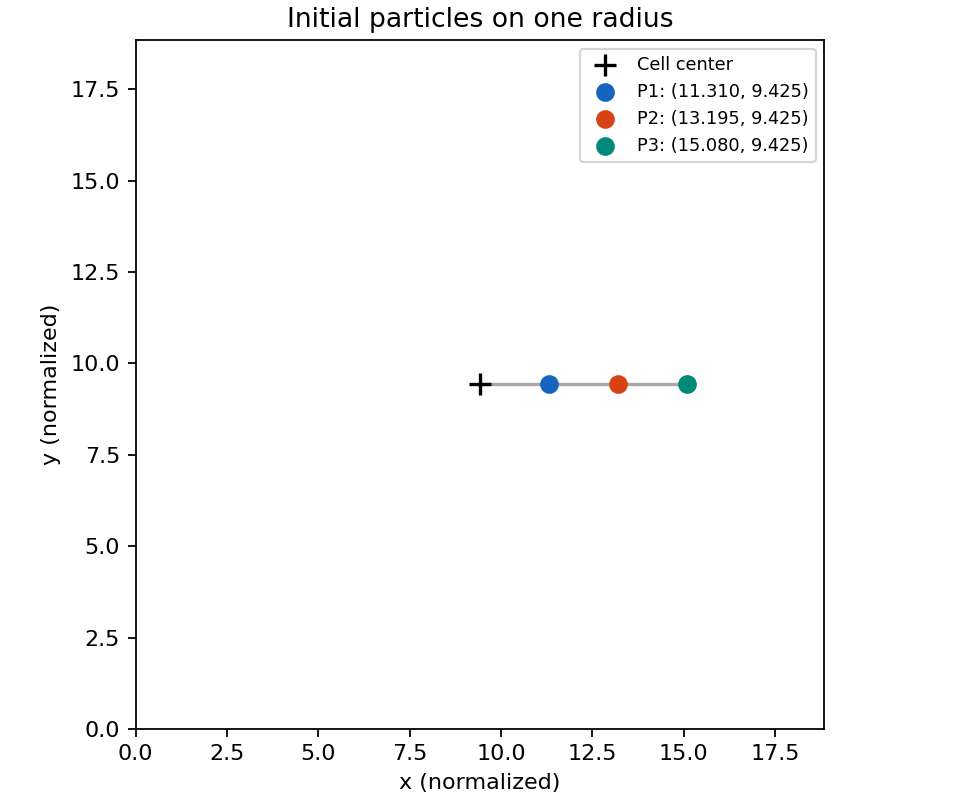

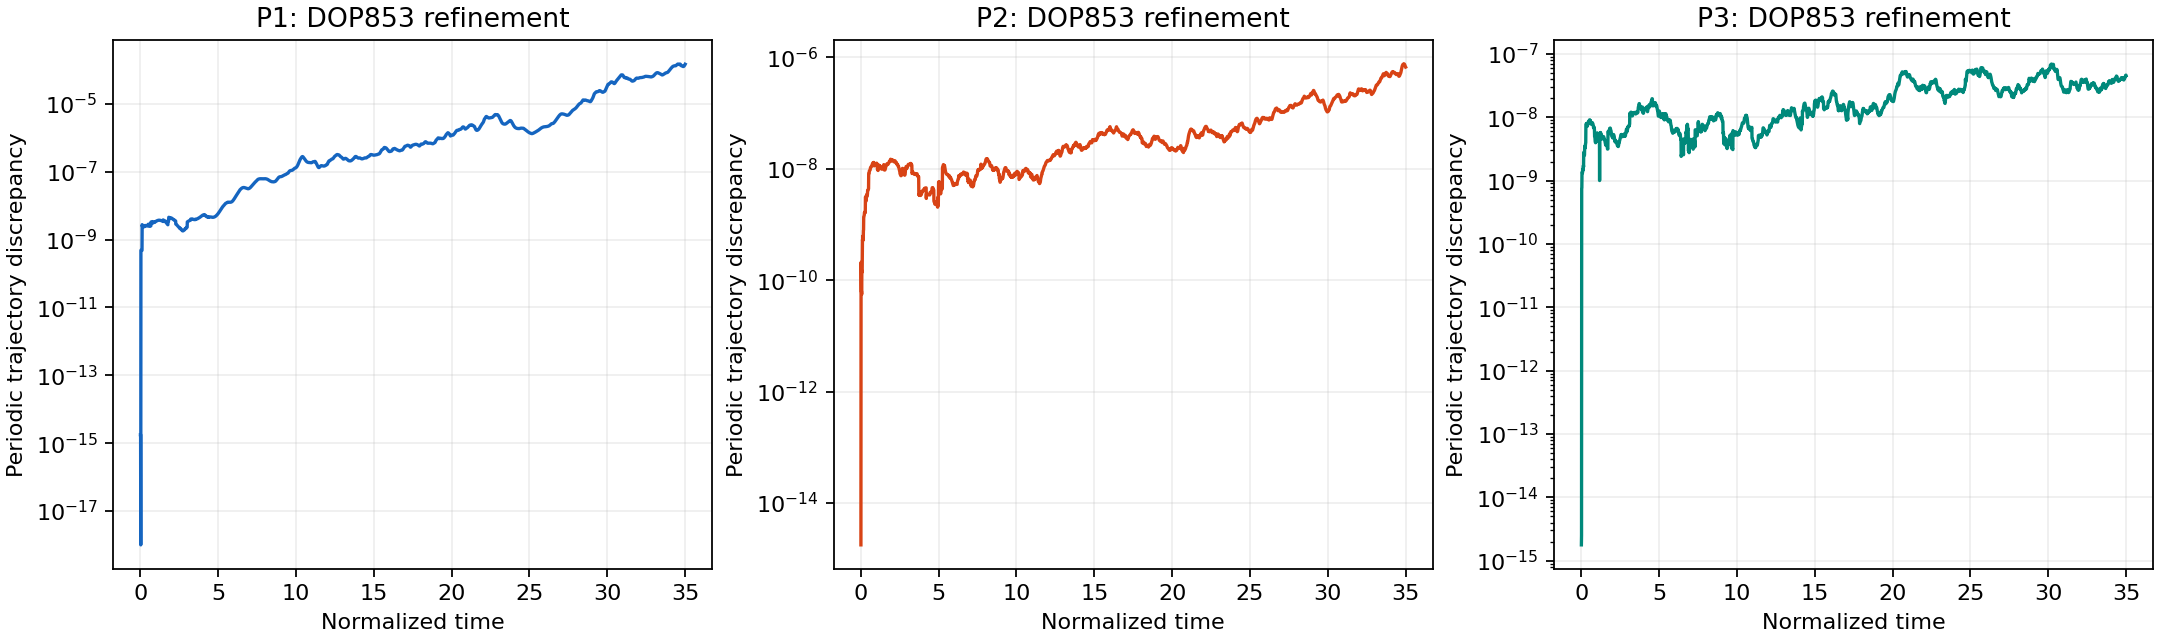

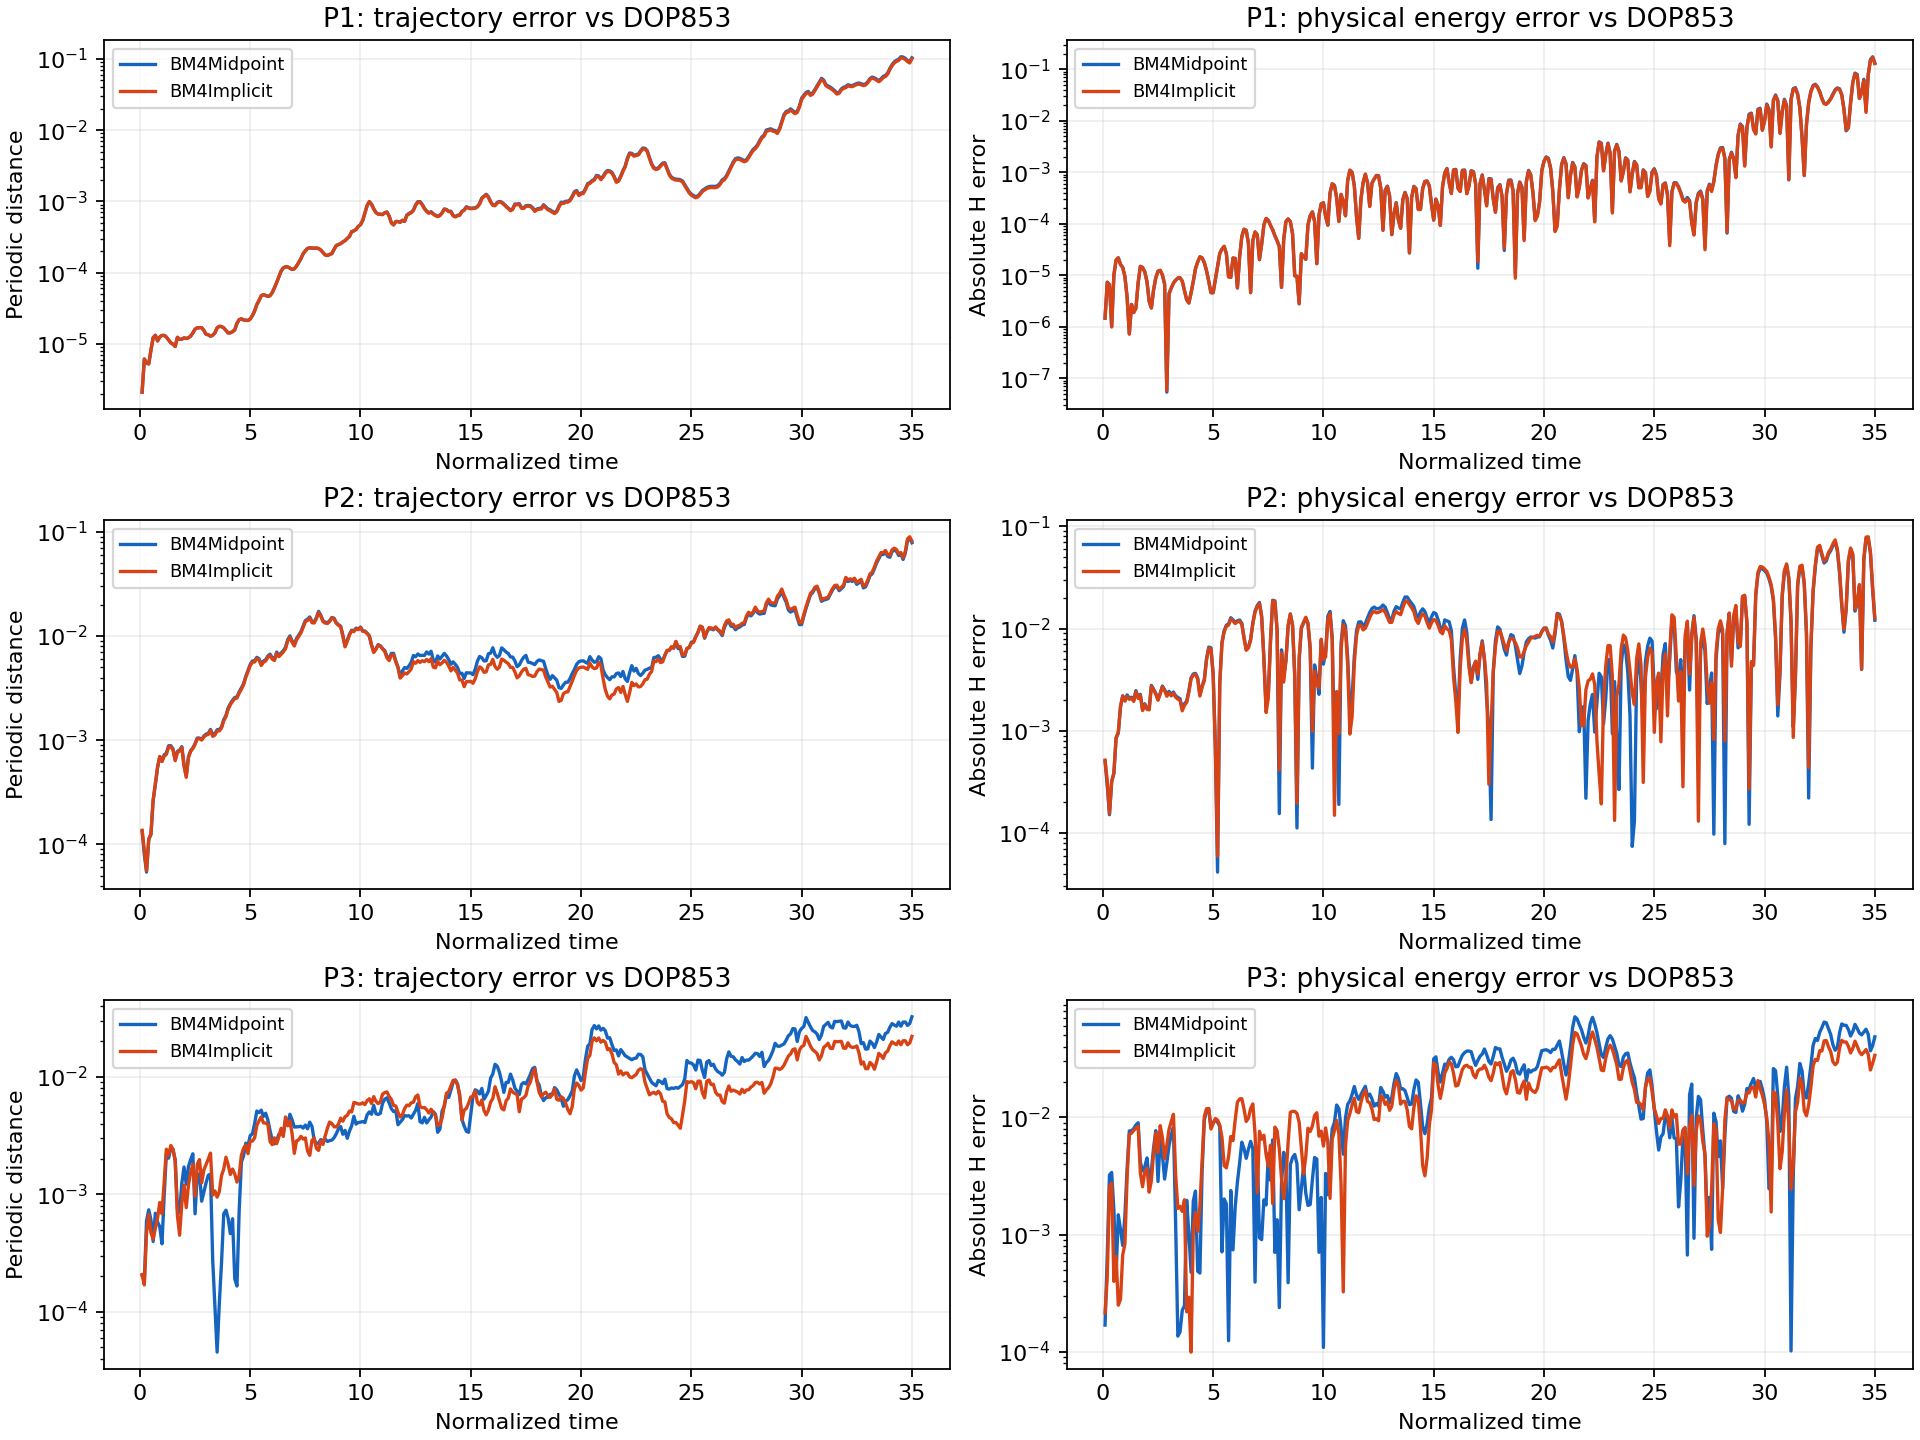

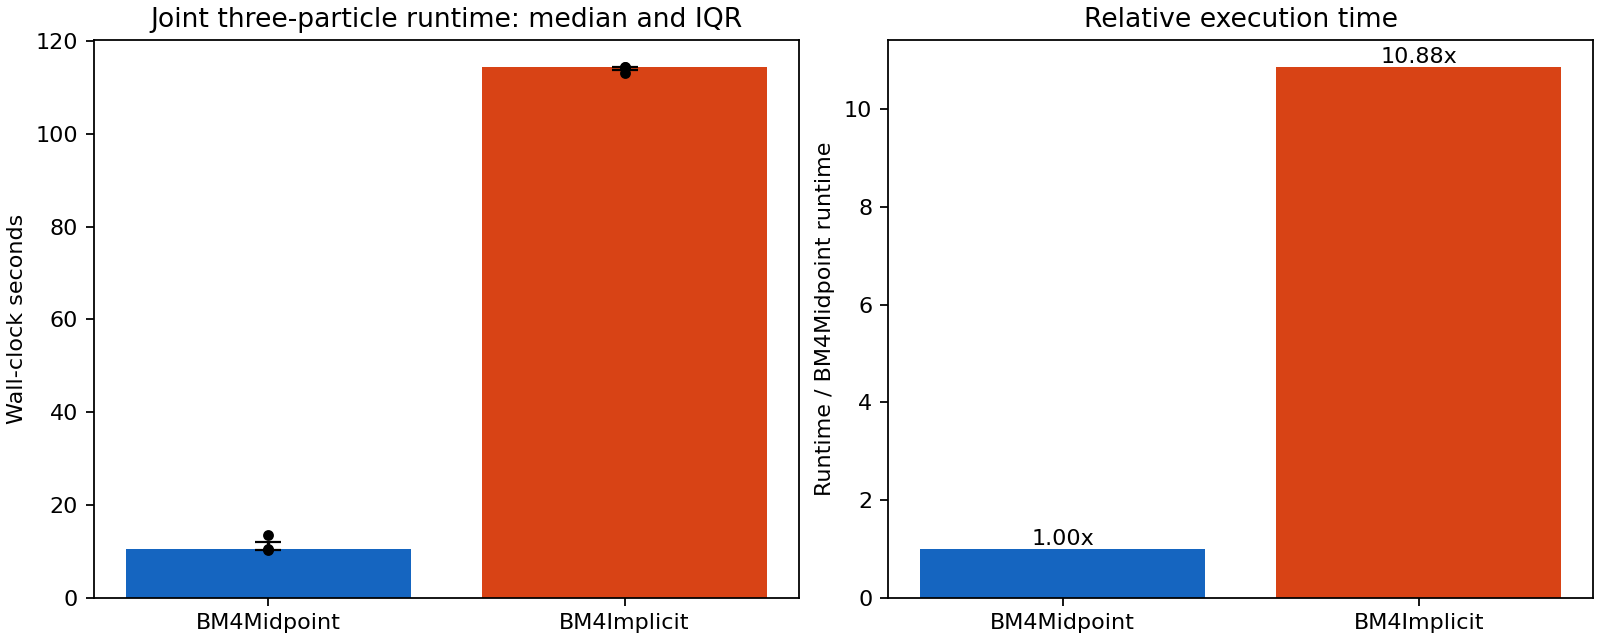

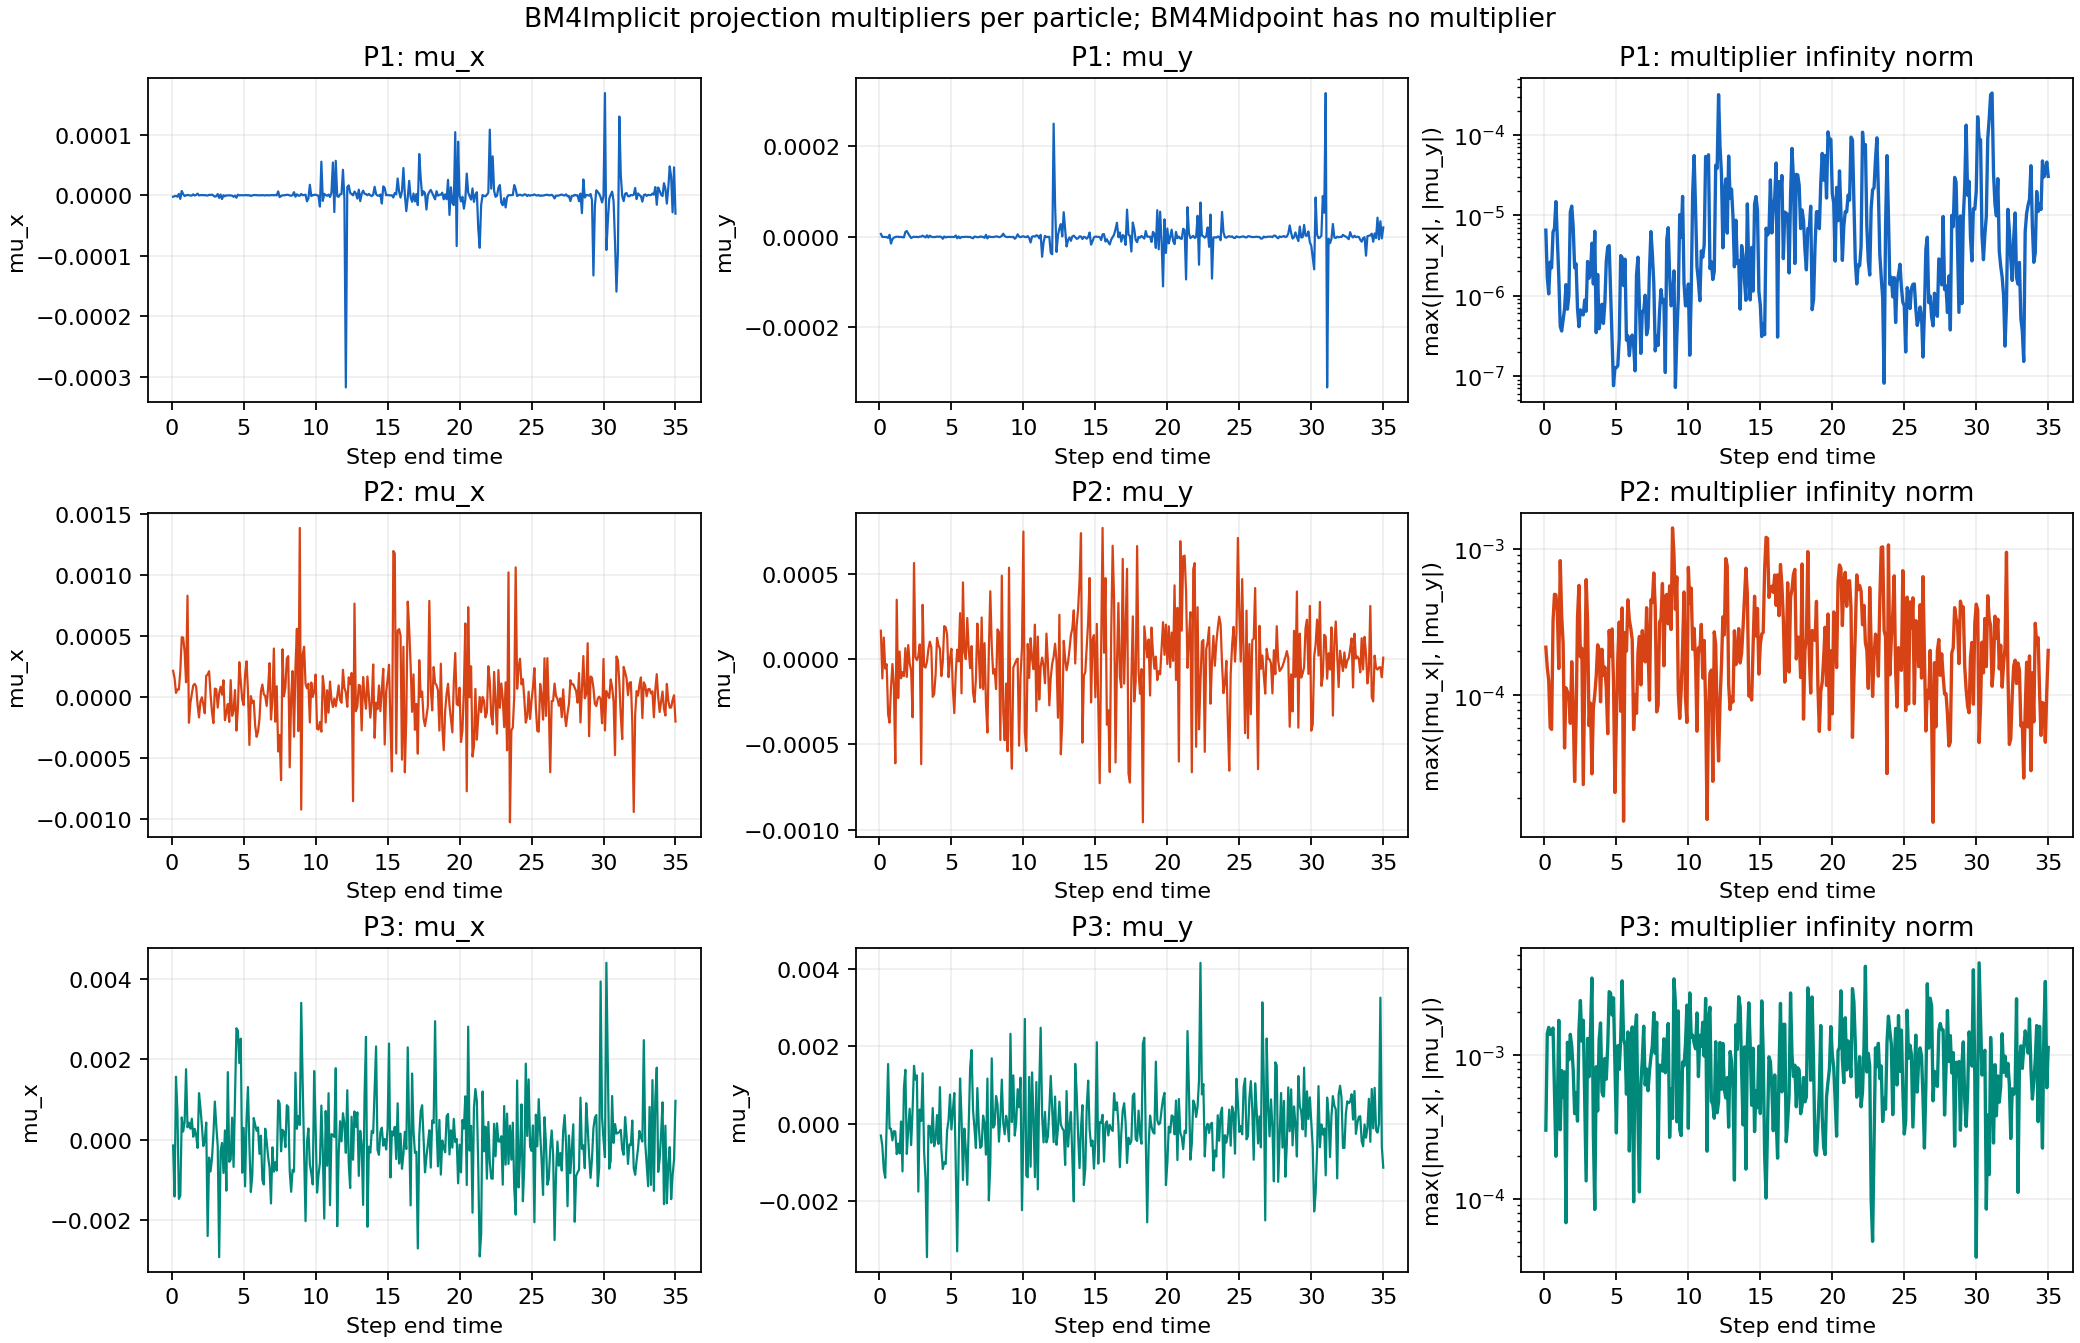

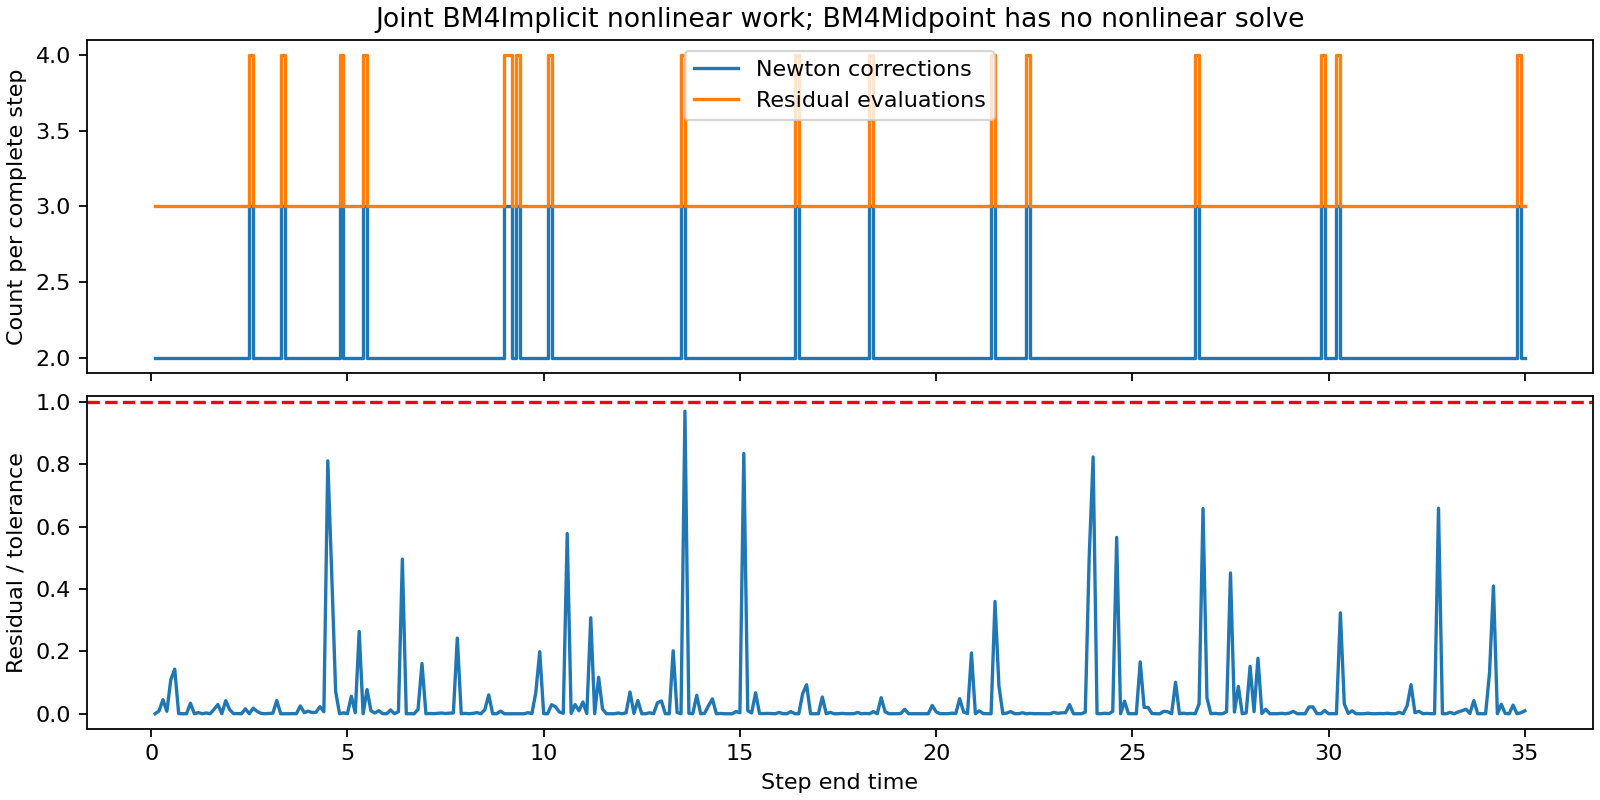

In [5]:
if render_outputs or run_integrations:
    render_bm4_comparison(potential, arrays, metadata, output,
        frames=ANIMATION_FRAMES, fps=ANIMATION_FPS, render_animation=run_integrations)
for name in ('initial_particles', 'reference_validation', 'accuracy', 'runtime', 'multipliers', 'nonlinear_work'):
    display(Image(filename=str(output / f'{name}.png')))
display(Video(filename=str(output / 'trajectories.mp4'), embed=True, width=1100))